In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

os.makedirs("artifacts", exist_ok=True)

Используемое устройство: cuda


In [2]:
raw_datasets = load_dataset("emotion", trust_remote_code=True)

labels = raw_datasets["train"].features["label"].names
id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

print(f"Классы датасета: {labels}")
print(f"Пример данных: {raw_datasets['train'][0]}")

df_train = pd.DataFrame(raw_datasets["train"])
df_train["label_name"] = df_train["label"].map(id2label)
print("\nРаспределение классов:")
print(df_train["label_name"].value_counts())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Классы датасета: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Пример данных: {'text': 'i didnt feel humiliated', 'label': 0}

Распределение классов:
label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [3]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

sample_text = "I feel so happy to finally finish this homework!"
encoded = tokenizer(sample_text)

print(f"Исходный текст: {sample_text}")
print(f"Токены: {tokenizer.convert_ids_to_tokens(encoded['input_ids'])}")
print(f"Input IDs: {encoded['input_ids']}")
print(f"Attention Mask: {encoded['attention_mask']}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Исходный текст: I feel so happy to finally finish this homework!
Токены: ['[CLS]', 'i', 'feel', 'so', 'happy', 'to', 'finally', 'finish', 'this', 'homework', '!', '[SEP]']
Input IDs: [101, 1045, 2514, 2061, 3407, 2000, 2633, 3926, 2023, 19453, 999, 102]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [4]:
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if torch.cuda.is_available() else -1)

test_samples = raw_datasets["test"]["text"][:3]
results = classifier(test_samples)

for text, res in zip(test_samples, results):
    print(f"Текст: {text}")
    print(f"Предсказание SST-2: {res['label']} (score: {res['score']:.4f})\n")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Текст: im feeling rather rotten so im not very ambitious right now
Предсказание SST-2: NEGATIVE (score: 0.9998)

Текст: im updating my blog because i feel shitty
Предсказание SST-2: NEGATIVE (score: 0.9995)

Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Предсказание SST-2: POSITIVE (score: 0.9993)



In [5]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=64)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro")
    }

training_args = TrainingArguments(
    output_dir="model_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.606659,0.213231,0.922000,0.899071
2,0.167852,0.154273,0.938500,0.914080
3,0.113863,0.157773,0.935000,0.911130


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1500, training_loss=0.2961245142618815, metrics={'train_runtime': 309.1321, 'train_samples_per_second': 155.273, 'train_steps_per_second': 4.852, 'total_flos': 644648902596864.0, 'train_loss': 0.2961245142618815, 'epoch': 3.0})

Результаты на Test: {'eval_loss': 0.18047742545604706, 'eval_accuracy': 0.921, 'eval_f1_macro': 0.8783000479067816, 'eval_runtime': 3.2672, 'eval_samples_per_second': 612.146, 'eval_steps_per_second': 19.283, 'epoch': 3.0}


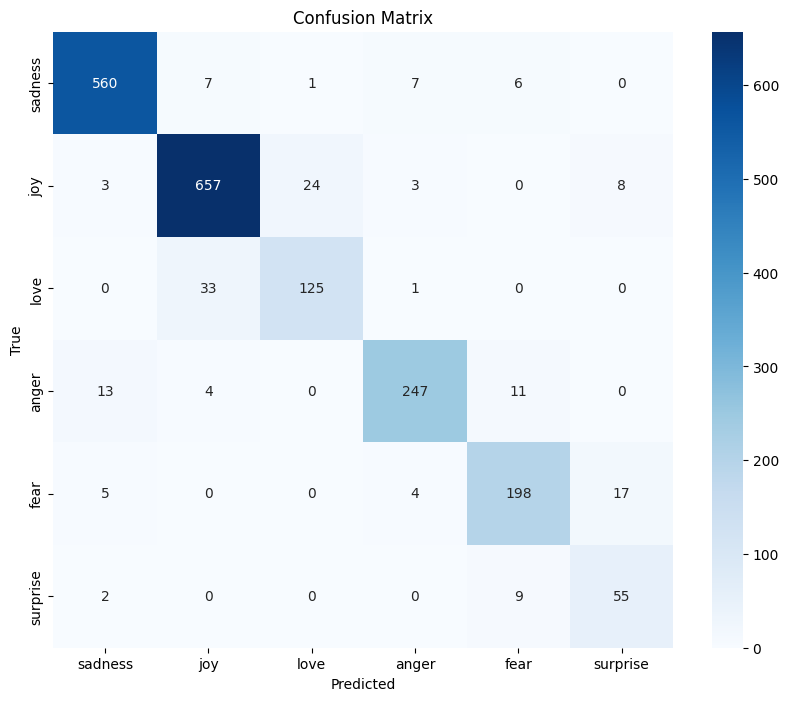

Артефакты сохранены в папку artifacts/


In [9]:
# Оценка на тестовом наборе
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Результаты на Test: {test_results}")

# Получение предсказаний для матрицы ошибок и CSV
predictions_output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

# Матрица ошибок
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

# Сохранение sample_predictions.csv
df_preds = pd.DataFrame({
    "text": raw_datasets["test"]["text"],
    "true_label": [id2label[i] for i in true_labels],
    "pred_label": [id2label[i] for i in preds]
})
df_preds.head(100).to_csv("artifacts/sample_predictions.csv", index=False)
print("Артефакты сохранены в папку artifacts/")

In [10]:
# Поиск ошибок
wrong_preds = df_preds[df_preds["true_label"] != df_preds["pred_label"]]
print("Примеры ошибок модели:")
display(wrong_preds.head(5))

Примеры ошибок модели:


,text,true_label,pred_label
10,i don t feel particularly agitated,fear,anger
67,i feel a bit stressed even though all the thin...,anger,sadness
86,i feel like i am in paradise kissing those swe...,joy,love
93,i was feeling weird the other day and it went ...,fear,surprise
94,when a friend dropped a frog down my neck,anger,fear


### Анализ ошибок (Error Analysis)
- Пересечение смыслов: Модель часто путает классы joy и love, так как в коротких текстах их лексика сильно совпадает.

- Сложные эмоции: Ошибки возникают в предложениях со смешанным контекстом (например, страх и гнев одновременно), где модель выбирает только одну доминирующую метку.

- Неявные триггеры: В некоторых случаях модель опирается на отдельные эмоционально окрашенные слова, игнорируя общий саркастический или нейтральный тон фразы.